# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

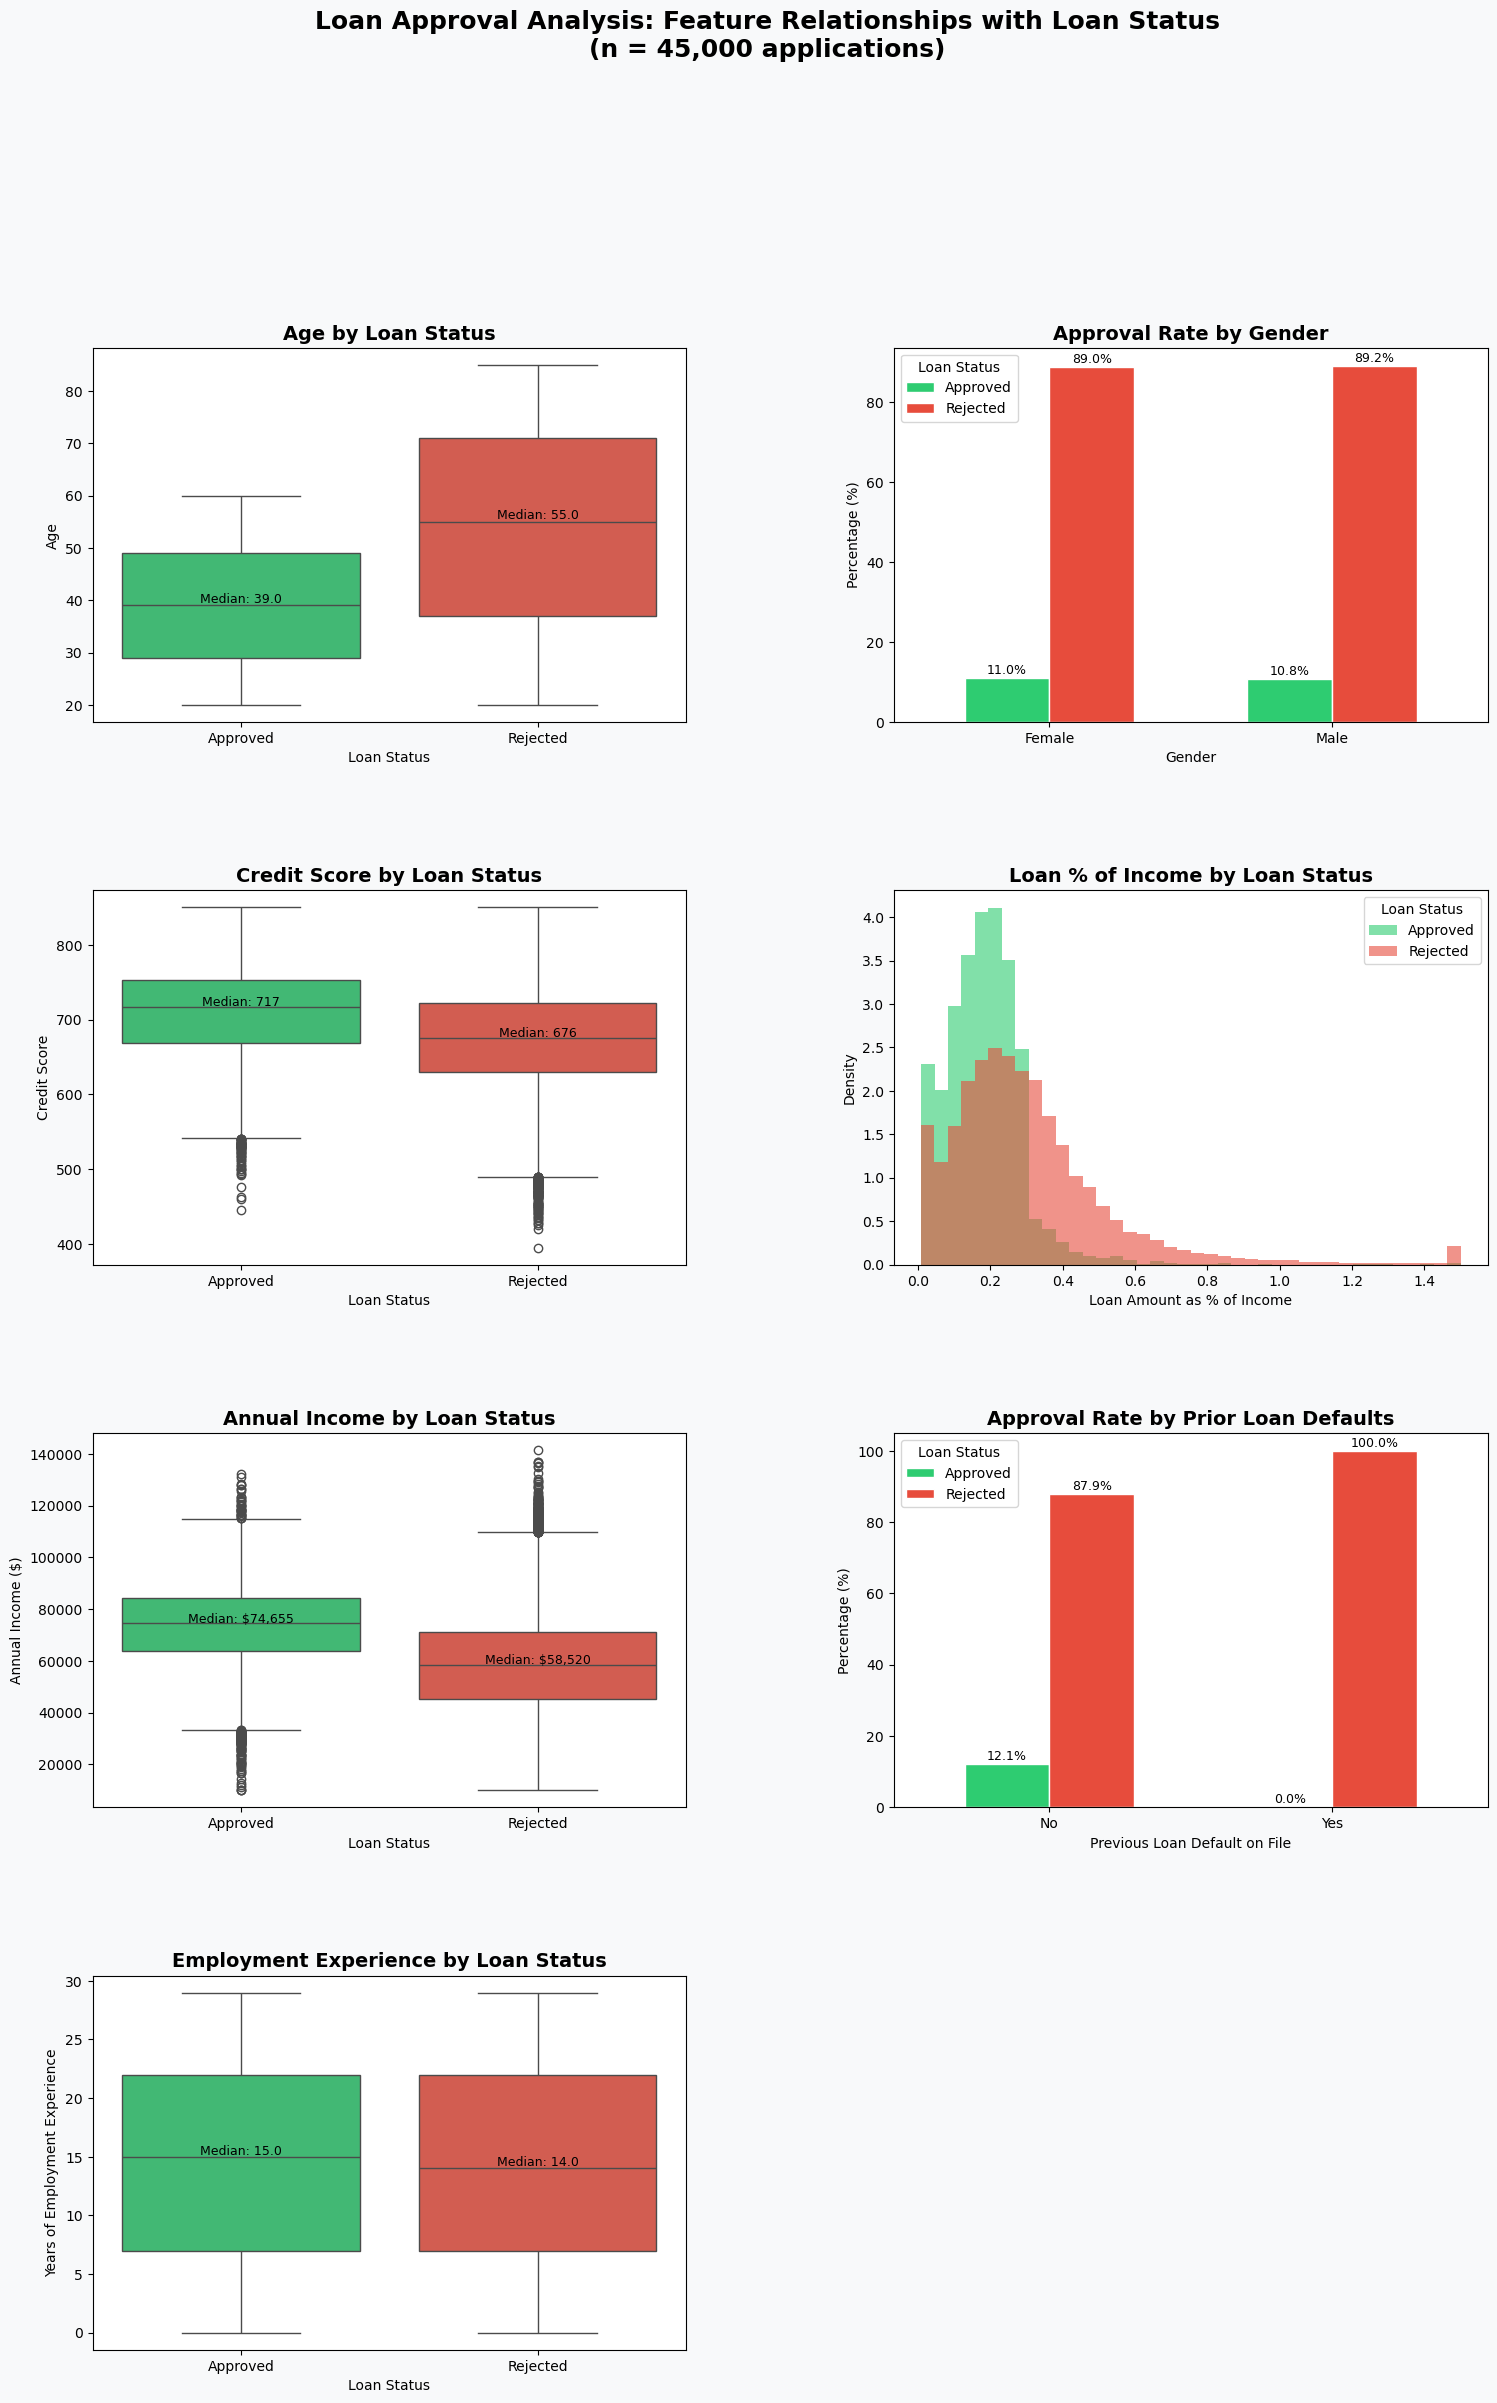

Visualizations saved.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

df = pd.read_csv('loan_data.csv')
df['Loan Status'] = df['loan_status'].map({1: 'Approved', 0: 'Rejected'})

palette = {'Approved': '#2ecc71', 'Rejected': '#e74c3c'}
colors = ['#2ecc71', '#e74c3c']

fig = plt.figure(figsize=(18, 26))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df, x='Loan Status', y='person_age', hue='Loan Status',
            palette=palette, ax=ax1, order=['Approved','Rejected'], legend=False)
ax1.set_title('Age by Loan Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Loan Status'); ax1.set_ylabel('Age')
medians = df.groupby('Loan Status')['person_age'].median()
for i, status in enumerate(['Approved','Rejected']):
    ax1.text(i, medians[status]+0.5, f'Median: {medians[status]:.1f}', ha='center', fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
gender_approval = df.groupby(['person_gender','Loan Status']).size().unstack(fill_value=0)
gender_pct = gender_approval.div(gender_approval.sum(axis=1), axis=0) * 100
gender_pct[['Approved','Rejected']].plot(kind='bar', ax=ax2, color=colors, edgecolor='white', width=0.6)
ax2.set_title('Approval Rate by Gender', fontsize=14, fontweight='bold')
ax2.set_xlabel('Gender'); ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(['Female','Male'], rotation=0)
ax2.legend(title='Loan Status')
for bar in ax2.patches:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)

ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df, x='Loan Status', y='credit_score', hue='Loan Status',
            palette=palette, ax=ax3, order=['Approved','Rejected'], legend=False)
ax3.set_title('Credit Score by Loan Status', fontsize=14, fontweight='bold')
ax3.set_xlabel('Loan Status'); ax3.set_ylabel('Credit Score')
medians = df.groupby('Loan Status')['credit_score'].median()
for i, status in enumerate(['Approved','Rejected']):
    ax3.text(i, medians[status]+2, f'Median: {medians[status]:.0f}', ha='center', fontsize=9)

ax4 = fig.add_subplot(gs[1, 1])
for status, color in palette.items():
    subset = df[df['Loan Status']==status]['loan_percent_income']
    ax4.hist(subset, bins=40, alpha=0.6, color=color, label=status, density=True)
ax4.set_title('Loan % of Income by Loan Status', fontsize=14, fontweight='bold')
ax4.set_xlabel('Loan Amount as % of Income'); ax4.set_ylabel('Density')
ax4.legend(title='Loan Status')

ax5 = fig.add_subplot(gs[2, 0])
sns.boxplot(data=df, x='Loan Status', y='person_income', hue='Loan Status',
            palette=palette, ax=ax5, order=['Approved','Rejected'], legend=False)
ax5.set_title('Annual Income by Loan Status', fontsize=14, fontweight='bold')
ax5.set_xlabel('Loan Status'); ax5.set_ylabel('Annual Income ($)')
medians = df.groupby('Loan Status')['person_income'].median()
for i, status in enumerate(['Approved','Rejected']):
    ax5.text(i, medians[status]+200, f'Median: ${medians[status]:,.0f}', ha='center', fontsize=9)

ax6 = fig.add_subplot(gs[2, 1])
default_approval = df.groupby(['previous_loan_defaults_on_file','Loan Status']).size().unstack(fill_value=0)
default_pct = default_approval.div(default_approval.sum(axis=1), axis=0) * 100
default_pct[['Approved','Rejected']].plot(kind='bar', ax=ax6, color=colors, edgecolor='white', width=0.6)
ax6.set_title('Approval Rate by Prior Loan Defaults', fontsize=14, fontweight='bold')
ax6.set_xlabel('Previous Loan Default on File'); ax6.set_ylabel('Percentage (%)')
ax6.set_xticklabels(['No','Yes'], rotation=0)
ax6.legend(title='Loan Status')
for bar in ax6.patches:
    height = bar.get_height()
    ax6.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)

ax7 = fig.add_subplot(gs[3, 0])
sns.boxplot(data=df, x='Loan Status', y='person_emp_exp', hue='Loan Status',
            palette=palette, ax=ax7, order=['Approved','Rejected'], legend=False)
ax7.set_title('Employment Experience by Loan Status', fontsize=14, fontweight='bold')
ax7.set_xlabel('Loan Status'); ax7.set_ylabel('Years of Employment Experience')
medians = df.groupby('Loan Status')['person_emp_exp'].median()
for i, status in enumerate(['Approved','Rejected']):
    ax7.text(i, medians[status]+0.2, f'Median: {medians[status]:.1f}', ha='center', fontsize=9)

fig.suptitle('Loan Approval Analysis: Feature Relationships with Loan Status\n(n = 45,000 applications)',
             fontsize=18, fontweight='bold', y=1.01)
plt.savefig('loan_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Visualizations saved.')

## Analysis

### Features That Drive Loan Approval

**1. Previous Loan Defaults on File:** This is the strongest data point. The bar chart shows that applicants with no prior default had a roughly 12% approval rate, while applicants with a prior default had a 0% approval rate. This is an apparent discriminating feature and almost certainly the dominant rule for the model.

**2. Credit Score:** Credit Score shows a clear separation in the boxplot. Approved applicants had a median credit score of 717, compared to 676 for rejected applicants. The interquartile ranges have some overlap, but the distributions are visibly shifted, indicating credit score has meaningful impact on the data.

**3. Loan Amount as a Percentage of Income:** Approved applicants are concentrated at lower values, while rejected applicants skew higher at about an 8% difference. Applicants asking for a loan that represents a large fraction of their income are far more likely to be rejected as it presents a clear financial risk.

### Features That Appear Less Influential

**4. Annual Income:** Income has similar distributions between approved and rejected applicants. The boxplots are nearly identical, suggesting income alone is not a major driver since `loan_percent_income` captures the relevant signal more directly.

**5. Employment Experience:** Both approved and rejected applicants have very similar median years of experience, with heavily overlapping distributions. This feature appears to have little relationship with loan outcome.

---

### Age and Gender

**Age** shows a distinct pattern favoring younger applicants. Approved applicants had a median age of 39, while rejected applicants had a median age of 55. Younger applicants were approved at substantially higher rates. 

**Gender**, however, shows equal footing. Both genders were approved at around 11%. The bar chart confirms near-identical approval rates, so gender does not appear to be driving model decisions..

---

## Should the Institution Be Concerned?

**Yes:** Specifically regarding age, the 16-year median age gap between approved and rejected applicants is a significant red flag. Under the Equal Credit Opportunity Act (ECOA) and the Fair Housing Act, age is a protected characteristic, and a model that systematically disadvantages older applicants faces significant legal exposure. Even if age was not explicitly included as a feature, correlated features like employment experience and credit history length could produce the same disparate impact. The institution should audit whether or not age is influencing model outcomes; because if the disparity cannot be explained by legitimate financial factors, the institution faces real legal risk under the ECOA.